In [1]:
import numpy as np
import sys,os
import MAS_library as MASL
import pickle as pk
import h5py as h5
from ngp_funcs import NGP_xyz_prop 
import skimage.measure as skmeasure


%load_ext Cython


In [2]:
# import numpy as np

# # Create the array
# arr = np.arange(1000)

# # Split into 8 equal parts
# split_arr = np.array_split(arr, 8)

# # Select the last 7.5% from each part and concatenate
# result = np.concatenate([part[int(0.925 * len(part)):] for part in split_arr])

# print(result)
import dill
import pickle as pk
ldir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/'
df = pk.load(open(ldir + 'mcmc_v9fixbaryon_probe_xip_xim_modelmatter_halofit_deproj_cib_1p7_dBeta_samples_4500_warmup_3500_num_chains_64_treedepth_5_gtysc_True_Y3xipmsc_True.pkl','rb'))
# df = pk.load(open(ldir + 'mcmc_v9fixbaryon_probe_xip_xim_modelmatter_halofit_deproj_cib_1p7_dBeta_samples_4500_warmup_3500_num_chains_64_treedepth_5_gtysc_True_Y3xipmsc_True.pkl','rb'))




In [3]:
def mat_reshape(mat, grid1, grid2):
    '''
    Reshape input mat into (grid1, grid1, grid1, grid2, grid2, grid2) shape
    '''
    if len(mat.shape) == 3:
        mat_rs = np.reshape(mat, (grid1, grid2, grid1, grid2, grid1, grid2))
    else:
        mat_rs = np.reshape(mat, (grid1, grid2, grid1, grid2, grid1, grid2, *mat.shape[3:]))

    mat_rs = np.moveaxis(mat_rs, 1, 2)
    mat_rs = np.moveaxis(mat_rs, 4, 3)
    mat_rs = np.moveaxis(mat_rs, 3, 2)
    return mat_rs


def get_padded_mat(Npart, n_pad, grid_sbox, grid):
    Npart_pad = np.pad(Npart, n_pad, 'wrap')

    Npart_pad1 = np.zeros((grid, grid, grid, grid_sbox + 2*n_pad, grid_sbox + 2*n_pad, grid_sbox + 2*n_pad))
    fac = (grid_sbox + 2*n_pad)//grid_sbox    
    Npart_pad1_reduce = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox))    
    xstart, ystart, zstart = n_pad, n_pad, n_pad
    for jx in range(grid):
        for jy in range(grid):
            for jz in range(grid):
                Npart_pad1[jx, jy, jz] = Npart_pad[xstart + jx * grid_sbox - n_pad:xstart + (jx + 1) * grid_sbox + n_pad,
                                                        ystart + jy * grid_sbox - n_pad:ystart + (jy + 1) * grid_sbox + n_pad,
                                                        zstart + jz * grid_sbox - n_pad:zstart + (jz + 1) * grid_sbox + n_pad]

                Npart_pad1_reduce[jx, jy, jz] = skmeasure.block_reduce(Npart_pad1[jx, jy, jz], (fac, fac, fac), np.mean)
    return Npart_pad1_reduce, Npart_pad1

def process_LH_sim(isim_fid, grid_sbox = 32):
    # nrand_sel_box = 128
    nrand_sel_box = 512
    norm_delta = 500
    norm_vel = 500
    BoxSize = 25.
    grid = 8
    
    MAS_type = 'NGP'
    grid_tot = grid_sbox * grid
    snapnums = [90, 84, 78, 70, 60]
    
    
    if nrand_sel_box < grid**3:
        import numpy as np
        np.random.seed(0)
        ind_all = np.arange(grid**3)
        rand_sel = (np.random.permutation(ind_all)[:nrand_sel_box]).astype(int)
    else:
        import numpy as np
        rand_sel = np.arange(grid**3)
    
    sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH/DMO_fields'
    savefname_dmo_fields = f'{sdir}/DMO_fields_grid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_MAS_{MAS_type}_nsnaps_{len(snapnums)}.pkl'
    
    
    for js, snapnum in enumerate(snapnums):
        root = '/work/hdd/bdne/spandey3/camels_tng/DMO/LH'
        snap_fname =  f'{root}/LH_{isim_fid}/snapshot_0{snapnum}.hdf5'
    
        np.random.seed(0)
        df = h5.File(snap_fname, 'r')                
        pos_m_truth = df['PartType1']['Coordinates'][()]/1000.
        vel_m_truth = df['PartType1']['Velocities'][()]
        ids_m_truth = np.arange(len(pos_m_truth))
    
        rho_bar = len(pos_m_truth)/(BoxSize**3)
        vol_vox = (BoxSize/grid_tot)**3
        N_bar_vox = rho_bar * vol_vox
    
        Npart = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
        MASL.MA(np.float32(pos_m_truth), Npart, BoxSize, MAS_type, verbose=False)
    
        Npart /= N_bar_vox
        Npart /= norm_delta
    
        Npart_rs = mat_reshape(Npart, grid, grid_sbox)
    
        npad1 = grid_sbox
        Npart_pad1_rs, _ = get_padded_mat(Npart, int(npad1), grid_sbox, grid)
    
        npad2 = 2*grid_sbox
        Npart_pad2_rs, _ = get_padded_mat(Npart, int(npad2), grid_sbox, grid)
    
        vel_m_part = np.float32(np.zeros((grid_tot, grid_tot, grid_tot, 3)))
    
        Npart_cic = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
        MASL.MA(np.float32(pos_m_truth), Npart_cic, BoxSize, 'CIC', verbose=False)
        for jc in range(3):
            mom_jc = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
            MASL.MA(np.float32(pos_m_truth), mom_jc, BoxSize, 'CIC', verbose=False, W=vel_m_truth[:,jc].astype(np.float32))
            vel_m_jc = mom_jc/Npart_cic
            vel_m_jc[~np.isfinite(vel_m_jc)] = 0.0
            vel_m_part[..., jc] = vel_m_jc/norm_vel
    
        vel_m_part_rs = mat_reshape(vel_m_part, grid, grid_sbox)
    
        dmo_fields_all_snap = np.concat((Npart_rs[...,None], Npart_pad1_rs[...,None], Npart_pad2_rs[...,None], vel_m_part_rs), axis=-1)
    
        if js == 0:
            dmo_fields_all = dmo_fields_all_snap
        else:
            dmo_fields_all = np.concatenate((dmo_fields_all, dmo_fields_all_snap), axis=-1)
    
    dmo_fields_all_rs = dmo_fields_all.reshape((grid**3, *dmo_fields_all.shape[3:]))
    
    saved = {'dmo_fields_all': dmo_fields_all_rs.astype(np.float32)[rand_sel, ...],
             'snapnums': snapnums,
            'rand_sel': rand_sel,
            'norm_delta': norm_delta,
            'norm_vel': norm_vel,
             'grid_sbox':grid_sbox,
             'grid':grid,
             'MAS_type':MAS_type         
            }
    pk.dump(saved, open(savefname_dmo_fields, 'wb'))
    


In [4]:
from tqdm import tqdm

# isim_fid_array = np.arange(980,1000)
# isim_fid_array = np.arange(975,1000)
import numpy as np
arr = np.arange(1000)
split_arr = np.array_split(arr, 8)
isim_fid_array = np.concatenate([part[int(0.925 * len(part)):] for part in split_arr])


for isim in tqdm(isim_fid_array):
    process_LH_sim(isim, 16)




  0%|          | 0/80 [00:00<?, ?it/s]/tmp/ipykernel_1920995/1850403479.py:94: RuntimeWarning: invalid value encountered in divide
  vel_m_jc = mom_jc/Npart_cic
100%|██████████| 80/80 [18:13<00:00, 13.67s/it]


In [7]:
import numpy as np
import sys,os
import MAS_library as MASL
import pickle as pk
import h5py as h5
from ngp_funcs import NGP_xyz_prop 
import skimage.measure as skmeasure
import ast

# add_space_token = bool(ast.literal_eval(sys.argv[-1]))

def mat_reshape(mat, grid1, grid2):
    '''
    Reshape input mat into (grid1, grid1, grid1, grid2, grid2, grid2) shape
    '''
    if len(mat.shape) == 3:
        mat_rs = np.reshape(mat, (grid1, grid2, grid1, grid2, grid1, grid2))
    else:
        mat_rs = np.reshape(mat, (grid1, grid2, grid1, grid2, grid1, grid2, *mat.shape[3:]))

    mat_rs = np.moveaxis(mat_rs, 1, 2)
    mat_rs = np.moveaxis(mat_rs, 4, 3)
    mat_rs = np.moveaxis(mat_rs, 3, 2)
    return mat_rs


def get_padded_mat(Npart, n_pad, grid_sbox, grid):
    Npart_pad = np.pad(Npart, n_pad, 'wrap')

    Npart_pad1 = np.zeros((grid, grid, grid, grid_sbox + 2*n_pad, grid_sbox + 2*n_pad, grid_sbox + 2*n_pad))
    fac = (grid_sbox + 2*n_pad)//grid_sbox    
    Npart_pad1_reduce = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox))    
    xstart, ystart, zstart = n_pad, n_pad, n_pad
    for jx in range(grid):
        for jy in range(grid):
            for jz in range(grid):
                Npart_pad1[jx, jy, jz] = Npart_pad[xstart + jx * grid_sbox - n_pad:xstart + (jx + 1) * grid_sbox + n_pad,
                                                        ystart + jy * grid_sbox - n_pad:ystart + (jy + 1) * grid_sbox + n_pad,
                                                        zstart + jz * grid_sbox - n_pad:zstart + (jz + 1) * grid_sbox + n_pad]

                Npart_pad1_reduce[jx, jy, jz] = skmeasure.block_reduce(Npart_pad1[jx, jy, jz], (fac, fac, fac), np.mean)
    return Npart_pad1_reduce, Npart_pad1



def process_LH_sim(isim_fid):
    import numpy as np
    import sys,os
    import MAS_library as MASL
    import pickle as pk
    import h5py as h5
    from ngp_funcs import NGP_xyz_prop 
    import skimage.measure as skmeasure
    
    # nrand_sel_box = 128
    nrand_sel_box = 512 
    BoxSize = 25.
    grid = 8
    nvocab = 64
    # Mstar_cut = 8.75
    Mstar_cut = 9.0   
    grid_sbox = nvocab
    grid_tot = grid_sbox * grid
    
    prop_min = np.array([9.0, 26.5, 26.5, 26.5, -0.45])
    prop_max = np.array([12.0, 30.5, 30.5, 30.5, 0.45])
    
    Npoints_max_per_subvol = 40
    #sort by Mstar token:
    ind_token_to_sort = 3
    add_space_token = False
    # add_space_token = True
    
    dim_pos = 3
    dim_prop = len(prop_min)
    dim_tot = dim_pos + dim_prop
    
    start_token = nvocab + 1
    space_token = nvocab + 2
    pad_token = nvocab + 3
    end_token = nvocab + 4

    # import numpy as np
    # np.random.seed(0)
    # rand_sel = np.sort(np.random.randint(0, grid**3, nrand_sel_box)).astype(int)
    # rand_sel = (np.arange(grid**3)[:nrand_sel_box]).astype(int)
    if nrand_sel_box < grid**3:
        import numpy as np
        np.random.seed(0)
        ind_all = np.arange(grid**3)
        rand_sel = (np.random.permutation(ind_all)[:nrand_sel_box]).astype(int)
    else:
        rand_sel = np.arange(grid**3)
        
    sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH'
    snapnum = 90
    savefname_gals = f'{sdir}/gal_props/galaxy_props_snap_{snapnum}_grid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_nvocab{nvocab}_spacetoken_{add_space_token}_wSDSS_photometry_velx_Mstarcut_{Mstar_cut}.pkl'
    
    
    snap_dir_base = f'/work/hdd/bdne/spandey3/camels_tng/hydro/'
    group_catalog = f'{snap_dir_base}/LH/LH_{isim_fid}/groups_0{snapnum}.hdf5'
    photo_catalog = f'{snap_dir_base}/Photometry/IllustrisTNG/L25n256/LH/IllustrisTNG_LH_{isim_fid}_photometry.hdf5'
    # open the catalogue
    with h5.File(photo_catalog, "r") as hf:
        subhalo_index = np.array(hf[f"snap_0{snapnum}/SubhaloIndex"][:], dtype=int)
        g_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.g"][:])
        r_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.r"][:])
        i_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.i"][:])
    
    # Read the stellar masses of the subhalos/galaxies
    with h5.File(group_catalog, "r") as hf:
        M_star = np.log10(hf['Subhalo/SubhaloMassType'][:,4]*1e10 + 0.01) # Stellar masses in Msun/h
        pos = hf['Subhalo/SubhaloPos'][:]/1000.
        vel = hf['Subhalo/SubhaloVel'][:]/1000.
    
    M_star = M_star[subhalo_index]
    pos_h_truth = pos[subhalo_index]
    vel_h_truth = vel[subhalo_index][:,0]
    prop_truth_all = np.stack((M_star, g_band, r_band, i_band, vel_h_truth)).T
    # print(np.amin(vel_h_truth), np.amax(vel_h_truth))
    indsel = np.where(M_star > Mstar_cut)[0]
    prop_truth_all = prop_truth_all[indsel,:]
    pos_h_truth = pos_h_truth[indsel,:]
    
    
    dim_pos = pos_h_truth.shape[1]
    dim_prop = prop_truth_all.shape[1]
    
    
    Nhalos_truth = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
    MASL.NGP(np.float32(pos_h_truth), Nhalos_truth, BoxSize)
    Nhalos_truth_rs = np.reshape(Nhalos_truth, (grid, grid_sbox, grid, grid_sbox, grid, grid_sbox))
    Nhalos_truth_rs = mat_reshape(Nhalos_truth, grid, grid_sbox)
    
    nMax_points = int(np.amax(Nhalos_truth_rs))
    
    dfhalo_ngp_wxyz_props = np.float32(np.zeros((grid_tot, grid_tot, grid_tot, nMax_points, dim_pos + dim_prop)))
    NGP_xyz_prop(np.float32(pos_h_truth), np.float32(prop_truth_all), dfhalo_ngp_wxyz_props, BoxSize)
    dfhalo_ngp_wxyz_props_rs = mat_reshape(dfhalo_ngp_wxyz_props, grid, grid_sbox)
    
    
    if add_space_token:
        max_sentence_length = 1 + Npoints_max_per_subvol*dim_tot + 1 + (Npoints_max_per_subvol - 1)
    else:
        max_sentence_length = 1 + Npoints_max_per_subvol*dim_tot + 1
    
    bins_digitize = np.linspace(-1e-3, 1, nvocab)
    Ntot_sel_final = 0
    sentences_all = np.zeros((grid, grid, grid, max_sentence_length), dtype=np.int16)
    for jx in range(grid):
        for jy in range(grid):
            for jz in range(grid):
                all_points_props_here = dfhalo_ngp_wxyz_props_rs[jx, jy, jz,...]
                Npoints_here = Nhalos_truth_rs[jx, jy, jz]
                indsel = np.where(Npoints_here > 0)
                Npoints_sel = Npoints_here[indsel]
                Npoints_sel_tot = int(np.sum(Npoints_sel))
                all_points_props_here_sel = all_points_props_here[indsel]
                word_array_all = []
                if len(Npoints_sel) > 0:    
                    for jc1 in range(len(Npoints_sel)):
                        Npoints_jc = (Npoints_sel[jc1]).astype(np.int16)
                        for jc2 in range(Npoints_jc):
                            all_points_props_here_sel_per_point = (all_points_props_here_sel[jc1, jc2, :])
                            position_token = np.array([indsel[0][jc1],indsel[1][jc1],indsel[2][jc1]], dtype=np.int16)
                            props_tokens = []
                            all_props = all_points_props_here_sel_per_point[3:]
                            for jp in range(len(all_props)):
                                prop_norm = np.clip((all_props[jp] - prop_min[jp]) / (prop_max[jp] - prop_min[jp]), 0.001, 0.999)
                                prop_token = np.digitize(prop_norm, bins_digitize).astype(np.int16)
                                if prop_token == 0:
                                    print(jp, prop_norm, prop_token)
                                props_tokens.append(prop_token)
                            props_token = np.array(props_tokens, dtype=np.int16)
                            all_tokens = np.concatenate((position_token, props_tokens))
                            word_array_all.append(all_tokens)
                    word_array_all = np.array(word_array_all, dtype=np.int16)
                    tosort_token_all = word_array_all[:, ind_token_to_sort]
                    sort_inds = np.flip(np.argsort(tosort_token_all))
                    word_array_all = word_array_all[sort_inds]
                    if Npoints_sel_tot > Npoints_max_per_subvol:
                        # print(isim_fid, ' LH-SIM HAS MORE POINTS (',Npoints_sel_tot,Npoints_max_per_subvol, ') THAN MAXIMUM IN THE', jx, jy, jz, ' THIS SUBVOLUME!!! max-sent-length: ',max_sentence_length)
                        word_array_all = word_array_all[:Npoints_max_per_subvol]    
                    Ntot_sel_final += len(word_array_all)
                    if add_space_token:
                        space_array = (np.array(np.zeros(word_array_all.shape[0]) + space_token, dtype=np.int16))[:,None]
                        word_array_all_concat = np.concatenate((word_array_all, space_array), axis=1)
                        sentence_here = np.concatenate(([start_token],(word_array_all_concat).flatten()[:-1], [end_token]))
                    else:
                        sentence_here = np.concatenate(([start_token],(word_array_all).flatten(), [end_token]))
                else:
                    sentence_here = np.array([start_token, end_token], dtype=np.int16)
    
                npad = max_sentence_length - len(sentence_here)
                if npad > 0:
                    # pad_mat = np.array(np.zeros((npad, dim_tot)) + pad_token, dtype=np.int16)
                    # sentence_pad = pad_mat.flatten()
                    sentence_pad = np.array(np.zeros(npad) + pad_token, dtype=np.int16)
                    sentence_here = np.concatenate((sentence_here, sentence_pad))
                    
                sentences_all[jx, jy, jz] = sentence_here
    
    story_full = sentences_all.reshape((grid**3, max_sentence_length))
    if int(np.sum(Nhalos_truth)) > Ntot_sel_final:
        print(isim_fid, np.round(int(np.sum(Nhalos_truth))/Ntot_sel_final, 3))
    
    saved = {'story_full': story_full.astype(np.int16)[rand_sel, ...],
             # 'Nhalos_truth_rs':Nhalos_truth_rs,
            'max_sentence_length': max_sentence_length,
            'grid': grid,
            'grid_sbox': grid_sbox,
            'Npoints_max_per_subvol': Npoints_max_per_subvol,
            'BoxSize': BoxSize,
            'prop_min': prop_min,
            'prop_max': prop_max,
             'nvocab':nvocab,
            'start_token': start_token,
            'pad_token': pad_token,
            'end_token': end_token,
            'space_token': space_token,
            'bins_digitize':bins_digitize,
            'rand_sel': rand_sel
            }
    pk.dump(saved, open(savefname_gals, 'wb'))







In [8]:
# process_LH_sim(4)
from tqdm import tqdm
# for isim in tqdm(range(0, 1000)):
# for isim in tqdm(range(0, 1000)):
# for isim in tqdm(range(607, 1000)):
import numpy as np
arr = np.arange(1000)
split_arr = np.array_split(arr, 8)
isim_fid_array = np.concatenate([part[int(0.925 * len(part)):] for part in split_arr])

# for isim in tqdm(range(975, 1000)):    
for isim in tqdm(isim_fid_array):
    process_LH_sim(isim)




  5%|▌         | 4/80 [00:07<02:31,  1.99s/it]

118 1.051


 14%|█▍        | 11/80 [00:24<02:35,  2.26s/it]

240 1.04


 20%|██        | 16/80 [00:35<02:19,  2.17s/it]

...

 96%|█████████▋| 77/80 [02:45<00:08,  2.76s/it]

996 1.016


 99%|█████████▉| 79/80 [02:49<00:02,  2.28s/it]

998 1.158


100%|██████████| 80/80 [02:51<00:00,  2.14s/it]


In [9]:
isim_fid_array


array([115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 240, 241, 242,
       243, 244, 245, 246, 247, 248, 249, 365, 366, 367, 368, 369, 370,
       371, 372, 373, 374, 490, 491, 492, 493, 494, 495, 496, 497, 498,
       499, 615, 616, 617, 618, 619, 620, 621, 622, 623, 624, 740, 741,
       742, 743, 744, 745, 746, 747, 748, 749, 865, 866, 867, 868, 869,
       870, 871, 872, 873, 874, 990, 991, 992, 993, 994, 995, 996, 997,
       998, 999])

In [14]:
nvocab = 64
bins_digitize = np.linspace(-1e-3, 1, nvocab)
# len(bins_digitize)
bins_digitize



array([-0.001     ,  0.01488889,  0.03077778,  0.04666667,  0.06255556,
        0.07844444,  0.09433333,  0.11022222,  0.12611111,  0.142     ,
        0.15788889,  0.17377778,  0.18966667,  0.20555556,  0.22144444,
        0.23733333,  0.25322222,  0.26911111,  0.285     ,  0.30088889,
        0.31677778,  0.33266667,  0.34855556,  0.36444444,  0.38033333,
        0.39622222,  0.41211111,  0.428     ,  0.44388889,  0.45977778,
        0.47566667,  0.49155556,  0.50744444,  0.52333333,  0.53922222,
        0.55511111,  0.571     ,  0.58688889,  0.60277778,  0.61866667,
        0.63455556,  0.65044444,  0.66633333,  0.68222222,  0.69811111,
        0.714     ,  0.72988889,  0.74577778,  0.76166667,  0.77755556,
        0.79344444,  0.80933333,  0.82522222,  0.84111111,  0.857     ,
        0.87288889,  0.88877778,  0.90466667,  0.92055556,  0.93644444,
        0.95233333,  0.96822222,  0.98411111,  1.        ])

In [14]:
isim_fid = 990
nrand_sel_box = 512
norm_delta = 500
norm_vel = 500
BoxSize = 25.
grid = 8
grid_sbox = 16
MAS_type = 'NGP'
grid_tot = grid_sbox * grid
snapnums = [90, 84, 78, 70, 60]


if nrand_sel_box < grid**3:
    import numpy as np
    np.random.seed(0)
    ind_all = np.arange(grid**3)
    rand_sel = (np.random.permutation(ind_all)[:nrand_sel_box]).astype(int)
else:
    import numpy as np
    rand_sel = np.arange(grid**3)

sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH/DMO_fields'
savefname_dmo_fields = f'{sdir}/DMO_fields_grid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_MAS_{MAS_type}_nsnaps_{len(snapnums)}.pkl'


for js, snapnum in enumerate(snapnums):
    root = '/work/hdd/bdne/spandey3/camels_tng/DMO/LH'
    snap_fname =  f'{root}/LH_{isim_fid}/snapshot_0{snapnum}.hdf5'

    np.random.seed(0)
    df = h5.File(snap_fname, 'r')                
    pos_m_truth = df['PartType1']['Coordinates'][()]/1000.
    vel_m_truth = df['PartType1']['Velocities'][()]
    ids_m_truth = np.arange(len(pos_m_truth))

    rho_bar = len(pos_m_truth)/(BoxSize**3)
    vol_vox = (BoxSize/grid_tot)**3
    N_bar_vox = rho_bar * vol_vox

    Npart = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
    MASL.MA(np.float32(pos_m_truth), Npart, BoxSize, MAS_type, verbose=False)

    Npart /= N_bar_vox
    Npart /= norm_delta

    Npart_rs = mat_reshape(Npart, grid, grid_sbox)

    npad1 = grid_sbox
    Npart_pad1_rs, _ = get_padded_mat(Npart, int(npad1), grid_sbox, grid)

    npad2 = 2*grid_sbox
    Npart_pad2_rs, _ = get_padded_mat(Npart, int(npad2), grid_sbox, grid)

    vel_m_part = np.float32(np.zeros((grid_tot, grid_tot, grid_tot, 3)))

    Npart_cic = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
    MASL.MA(np.float32(pos_m_truth), Npart_cic, BoxSize, 'CIC', verbose=False)
    for jc in range(3):
        mom_jc = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
        MASL.MA(np.float32(pos_m_truth), mom_jc, BoxSize, 'CIC', verbose=False, W=vel_m_truth[:,jc].astype(np.float32))
        vel_m_jc = mom_jc/Npart_cic
        vel_m_jc[~np.isfinite(vel_m_jc)] = 0.0
        vel_m_part[..., jc] = vel_m_jc/norm_vel

    vel_m_part_rs = mat_reshape(vel_m_part, grid, grid_sbox)

    dmo_fields_all_snap = np.concat((Npart_rs[...,None], Npart_pad1_rs[...,None], Npart_pad2_rs[...,None], vel_m_part_rs), axis=-1)

    if js == 0:
        dmo_fields_all = dmo_fields_all_snap
    else:
        dmo_fields_all = np.concatenate((dmo_fields_all, dmo_fields_all_snap), axis=-1)

dmo_fields_all_rs = dmo_fields_all.reshape((grid**3, *dmo_fields_all.shape[3:]))


/tmp/ipykernel_166180/830315735.py:61: RuntimeWarning: invalid value encountered in divide
  vel_m_jc = mom_jc/Npart_cic


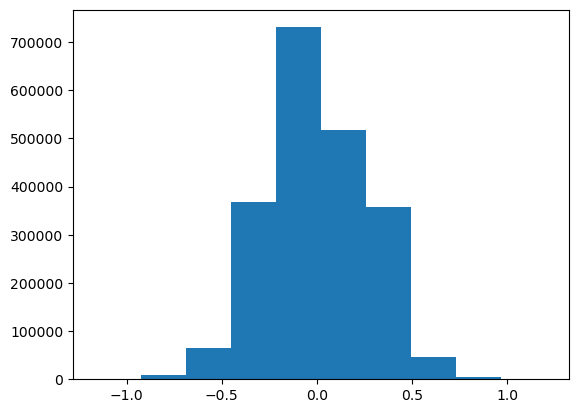

In [15]:
pl.figure()
_ = pl.hist(dmo_fields_all[...,-1].flatten())



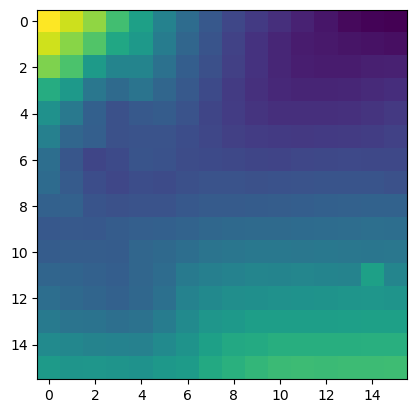

In [17]:
# dmo_fields_all.shape
import matplotlib.pyplot as pl
pl.figure()
pl.imshow(np.sum(dmo_fields_all[0,5,4,:,:,:,4], axis=0))




In [18]:
sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH/DMO_fields'
savefname_dmo_fields = f'{sdir}/DMO_fields_grid_{32}_isim_{isim_fid}_nrandsubsel_{512}_MAS_{MAS_type}_nsnaps_{len(snapnums)}.pkl'
df = pk.load(open(savefname_dmo_fields, 'rb'))
dmo_fields_all = df['dmo_fields_all']
dmo_fields_all = dmo_fields_all.reshape(8,8,8,*dmo_fields_all.shape[1:])



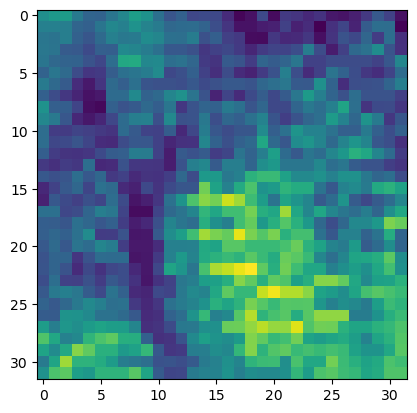

In [19]:
import matplotlib.pyplot as pl
pl.figure()
pl.imshow(np.sum(dmo_fields_all[0,5,4,:,:,:,4], axis=0))


In [1]:
import numpy as np
import sys,os
import MAS_library as MASL
import pickle as pk
import h5py as h5
from ngp_funcs import NGP_xyz_prop 
import skimage.measure as skmeasure
import ast

add_space_token = 0

def mat_reshape(mat, grid1, grid2):
    '''
    Reshape input mat into (grid1, grid1, grid1, grid2, grid2, grid2) shape
    '''
    if len(mat.shape) == 3:
        mat_rs = np.reshape(mat, (grid1, grid2, grid1, grid2, grid1, grid2))
    else:
        mat_rs = np.reshape(mat, (grid1, grid2, grid1, grid2, grid1, grid2, *mat.shape[3:]))

    mat_rs = np.moveaxis(mat_rs, 1, 2)
    mat_rs = np.moveaxis(mat_rs, 4, 3)
    mat_rs = np.moveaxis(mat_rs, 3, 2)
    return mat_rs


def get_padded_mat(Npart, n_pad, grid_sbox, grid):
    Npart_pad = np.pad(Npart, n_pad, 'wrap')

    Npart_pad1 = np.zeros((grid, grid, grid, grid_sbox + 2*n_pad, grid_sbox + 2*n_pad, grid_sbox + 2*n_pad))
    fac = (grid_sbox + 2*n_pad)//grid_sbox    
    Npart_pad1_reduce = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox))    
    xstart, ystart, zstart = n_pad, n_pad, n_pad
    for jx in range(grid):
        for jy in range(grid):
            for jz in range(grid):
                Npart_pad1[jx, jy, jz] = Npart_pad[xstart + jx * grid_sbox - n_pad:xstart + (jx + 1) * grid_sbox + n_pad,
                                                        ystart + jy * grid_sbox - n_pad:ystart + (jy + 1) * grid_sbox + n_pad,
                                                        zstart + jz * grid_sbox - n_pad:zstart + (jz + 1) * grid_sbox + n_pad]

                Npart_pad1_reduce[jx, jy, jz] = skmeasure.block_reduce(Npart_pad1[jx, jy, jz], (fac, fac, fac), np.mean)
    return Npart_pad1_reduce, Npart_pad1




def process_LH_sim(isim_fid):
    import numpy as np
    import sys,os
    import MAS_library as MASL
    import pickle as pk
    import h5py as h5
    from ngp_funcs import NGP_xyz_prop 
    import skimage.measure as skmeasure
    
    nrand_sel_box = 128
    # nrand_sel_box = 512 
    BoxSize = 25.
    grid = 8
    nvocab = 64
    # Mstar_cut = 8.75
    Mstar_cut = 9.0   
    grid_sbox = nvocab
    grid_tot = grid_sbox * grid
    
    prop_min = np.array([9.0, 26.5, 26.5, 26.5, -0.45])
    prop_max = np.array([12.0, 30.5, 30.5, 30.5, 0.45])
    
    Npoints_max_per_subvol = 40
    #sort by Mstar token:
    ind_token_to_sort = 3
    # add_space_token = False
    # add_space_token = True
    
    dim_pos = 3
    dim_prop = len(prop_min)
    dim_tot = dim_pos + dim_prop
    
    start_token = nvocab + 1
    space_token = nvocab + 2
    pad_token = nvocab + 3
    end_token = nvocab + 4

    # import numpy as np
    # np.random.seed(0)
    # rand_sel = np.sort(np.random.randint(0, grid**3, nrand_sel_box)).astype(int)
    # rand_sel = (np.arange(grid**3)[:nrand_sel_box]).astype(int)
    if nrand_sel_box < grid**3:
        import numpy as np
        np.random.seed(0)
        ind_all = np.arange(grid**3)
        rand_sel = (np.random.permutation(ind_all)[:nrand_sel_box]).astype(int)
    else:
        rand_sel = np.arange(grid**3)
        
    sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH'
    snapnum = 90
    savefname_gals = f'{sdir}/gal_props/galaxy_props_snap_{snapnum}_grid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_nvocab{nvocab}_spacetoken_{add_space_token}_wSDSS_photometry_velx_Mstarcut_{Mstar_cut}.pkl'
    
    
    snap_dir_base = f'/work/hdd/bdne/spandey3/camels_tng/hydro/'
    group_catalog = f'{snap_dir_base}/LH/LH_{isim_fid}/groups_0{snapnum}.hdf5'
    photo_catalog = f'{snap_dir_base}/Photometry/IllustrisTNG/L25n256/LH/IllustrisTNG_LH_{isim_fid}_photometry.hdf5'
    # open the catalogue
    with h5.File(photo_catalog, "r") as hf:
        subhalo_index = np.array(hf[f"snap_0{snapnum}/SubhaloIndex"][:], dtype=int)
        g_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.g"][:])
        r_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.r"][:])
        i_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.i"][:])
    
    # Read the stellar masses of the subhalos/galaxies
    with h5.File(group_catalog, "r") as hf:
        M_star = np.log10(hf['Subhalo/SubhaloMassType'][:,4]*1e10 + 0.01) # Stellar masses in Msun/h
        pos = hf['Subhalo/SubhaloPos'][:]/1000.
        vel = hf['Subhalo/SubhaloVel'][:]/1000.
    
    M_star = M_star[subhalo_index]
    pos_h_truth = pos[subhalo_index]
    vel_h_truth = vel[subhalo_index][:,0]
    prop_truth_all = np.stack((M_star, g_band, r_band, i_band, vel_h_truth)).T
    # print(np.amin(vel_h_truth), np.amax(vel_h_truth))
    indsel = np.where(M_star > Mstar_cut)[0]
    prop_truth_all = prop_truth_all[indsel,:]
    pos_h_truth = pos_h_truth[indsel,:]
    
    
    dim_pos = pos_h_truth.shape[1]
    dim_prop = prop_truth_all.shape[1]
    
    
    Nhalos_truth = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
    MASL.NGP(np.float32(pos_h_truth), Nhalos_truth, BoxSize)
    Nhalos_truth_rs = np.reshape(Nhalos_truth, (grid, grid_sbox, grid, grid_sbox, grid, grid_sbox))
    Nhalos_truth_rs = mat_reshape(Nhalos_truth, grid, grid_sbox)
    
    nMax_points = int(np.amax(Nhalos_truth_rs))
    
    dfhalo_ngp_wxyz_props = np.float32(np.zeros((grid_tot, grid_tot, grid_tot, nMax_points, dim_pos + dim_prop)))
    NGP_xyz_prop(np.float32(pos_h_truth), np.float32(prop_truth_all), dfhalo_ngp_wxyz_props, BoxSize)
    dfhalo_ngp_wxyz_props_rs = mat_reshape(dfhalo_ngp_wxyz_props, grid, grid_sbox)
    
    
    if add_space_token:
        max_sentence_length = 1 + Npoints_max_per_subvol*dim_tot + 1 + (Npoints_max_per_subvol - 1)
    else:
        max_sentence_length = 1 + Npoints_max_per_subvol*dim_tot + 1
    
    bins_digitize = np.linspace(-1e-3, 1, nvocab)
    Ntot_sel_final = 0
    sentences_all = np.zeros((grid, grid, grid, max_sentence_length), dtype=np.int16)
    for jx in range(grid):
        for jy in range(grid):
            for jz in range(grid):
                all_points_props_here = dfhalo_ngp_wxyz_props_rs[jx, jy, jz,...]
                Npoints_here = Nhalos_truth_rs[jx, jy, jz]
                indsel = np.where(Npoints_here > 0)
                Npoints_sel = Npoints_here[indsel]
                Npoints_sel_tot = int(np.sum(Npoints_sel))
                all_points_props_here_sel = all_points_props_here[indsel]
                word_array_all = []
                if len(Npoints_sel) > 0:    
                    for jc1 in range(len(Npoints_sel)):
                        Npoints_jc = (Npoints_sel[jc1]).astype(np.int16)
                        for jc2 in range(Npoints_jc):
                            all_points_props_here_sel_per_point = (all_points_props_here_sel[jc1, jc2, :])
                            position_token = np.array([indsel[0][jc1],indsel[1][jc1],indsel[2][jc1]], dtype=np.int16)
                            props_tokens = []
                            all_props = all_points_props_here_sel_per_point[3:]
                            for jp in range(len(all_props)):
                                prop_norm = np.clip((all_props[jp] - prop_min[jp]) / (prop_max[jp] - prop_min[jp]), 0.001, 0.999)
                                prop_token = np.digitize(prop_norm, bins_digitize).astype(np.int16)
                                if prop_token == 0:
                                    print(jp, prop_norm, prop_token)
                                props_tokens.append(prop_token)
                            props_token = np.array(props_tokens, dtype=np.int16)
                            all_tokens = np.concatenate((position_token, props_tokens))
                            word_array_all.append(all_tokens)
                    word_array_all = np.array(word_array_all, dtype=np.int16)
                    tosort_token_all = word_array_all[:, ind_token_to_sort]
                    sort_inds = np.flip(np.argsort(tosort_token_all))
                    word_array_all = word_array_all[sort_inds]
                    if Npoints_sel_tot > Npoints_max_per_subvol:
                        # print(isim_fid, ' LH-SIM HAS MORE POINTS (',Npoints_sel_tot,Npoints_max_per_subvol, ') THAN MAXIMUM IN THE', jx, jy, jz, ' THIS SUBVOLUME!!! max-sent-length: ',max_sentence_length)
                        word_array_all = word_array_all[:Npoints_max_per_subvol]    
                    Ntot_sel_final += len(word_array_all)
                    if add_space_token:
                        space_array = (np.array(np.zeros(word_array_all.shape[0]) + space_token, dtype=np.int16))[:,None]
                        word_array_all_concat = np.concatenate((word_array_all, space_array), axis=1)
                        sentence_here = np.concatenate(([start_token],(word_array_all_concat).flatten()[:-1], [end_token]))
                    else:
                        sentence_here = np.concatenate(([start_token],(word_array_all).flatten(), [end_token]))
                else:
                    sentence_here = np.array([start_token, end_token], dtype=np.int16)
    
                npad = max_sentence_length - len(sentence_here)
                if npad > 0:
                    # pad_mat = np.array(np.zeros((npad, dim_tot)) + pad_token, dtype=np.int16)
                    # sentence_pad = pad_mat.flatten()
                    sentence_pad = np.array(np.zeros(npad) + pad_token, dtype=np.int16)
                    sentence_here = np.concatenate((sentence_here, sentence_pad))
                    
                sentences_all[jx, jy, jz] = sentence_here
    
    story_full = sentences_all.reshape((grid**3, max_sentence_length))
    if int(np.sum(Nhalos_truth)) > Ntot_sel_final:
        print(isim_fid, np.round(int(np.sum(Nhalos_truth))/Ntot_sel_final, 3))
    
    saved = {'story_full': story_full.astype(np.int16)[rand_sel, ...],
             # 'Nhalos_truth_rs':Nhalos_truth_rs,
            'max_sentence_length': max_sentence_length,
            'grid': grid,
            'grid_sbox': grid_sbox,
            'Npoints_max_per_subvol': Npoints_max_per_subvol,
            'BoxSize': BoxSize,
            'prop_min': prop_min,
            'prop_max': prop_max,
             'nvocab':nvocab,
            'start_token': start_token,
            'pad_token': pad_token,
            'end_token': end_token,
            'space_token': space_token,
            'bins_digitize':bins_digitize,
            'rand_sel': rand_sel
            }
    pk.dump(saved, open(savefname_gals, 'wb'))



In [2]:
# Npoints_here
# Npoints_sel_tot
from tqdm import tqdm
for ji in tqdm(range(1000)):
    process_LH_sim(ji)


  1%|          | 7/1000 [00:12<29:17,  1.77s/it]


KeyboardInterrupt: 

In [23]:
Npoints_sel


array([2., 5., 1., 1., 1., 1.], dtype=float32)